<a href="https://colab.research.google.com/github/shruti06754/customer-churn-prediction-system/blob/main/customer_churn_prediction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Libraries imported successfully")

Libraries imported successfully


# Create a simple customer dataset

In [2]:
np.random.seed(42)

customers = 500

data = pd.DataFrame({
    "CustomerID": range(1001, 1001 + customers),
    "Age": np.random.randint(18, 70, customers),
    "Tenure": np.random.randint(1, 72, customers),
    "MonthlyCharges": np.random.randint(20, 120, customers),
    "TotalCharges": np.random.randint(100, 8000, customers),
    "ServiceUsage": np.random.randint(1, 100, customers),
    "Contract": np.random.choice(
        ["Month-to-month", "One year", "Two year"],
        customers
    ),
    "Gender": np.random.choice(
        ["Male", "Female"],
        customers
    )
})

# Check the data

In [3]:
print("Rows:", len(data))

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

Rows: 500

Missing values:
CustomerID        0
Age               0
Tenure            0
MonthlyCharges    0
TotalCharges      0
ServiceUsage      0
Contract          0
Gender            0
dtype: int64

Duplicate rows:
0


# Data preprocessing

In [6]:
np.random.seed(42)

data["Churn"] = np.where(
    (data["Tenure"] < 12) & (data["MonthlyCharges"] > 70),
    "Yes",
    "No"
)

data["Gender"] = data["Gender"].map({
    "Male": 0,
    "Female": 1
})

data["Contract"] = data["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
})

data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})
data.head()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,ServiceUsage,Contract,Gender,Churn
0,1001,56,16,66,7927,20,NaN,NaN,0
1,1002,69,61,119,7842,60,NaN,NaN,0
2,1003,46,64,107,5529,24,NaN,NaN,0
3,1004,32,63,71,984,50,NaN,NaN,0
4,1005,60,69,75,7510,49,NaN,NaN,0


# Feature Engineering

In [7]:
data["AverageMonthlySpend"] = (
    data["TotalCharges"] / data["Tenure"]
)

data["AverageMonthlySpend"] = data["AverageMonthlySpend"].replace(
    [np.inf, -np.inf],
    np.nan
)

data["AverageMonthlySpend"] = data["AverageMonthlySpend"].fillna(
    data["MonthlyCharges"]
)
data = data.drop("CustomerID", axis=1)

data.head()

,Age,Tenure,MonthlyCharges,TotalCharges,ServiceUsage,Contract,Gender,Churn,AverageMonthlySpend
0,56,16,66,7927,20,NaN,NaN,0,495.437500
1,69,61,119,7842,60,NaN,NaN,0,128.557377
2,46,64,107,5529,24,NaN,NaN,0,86.390625
3,32,63,71,984,50,NaN,NaN,0,15.619048
4,60,69,75,7510,49,NaN,NaN,0,108.840580


# EDA — Churn Distribution

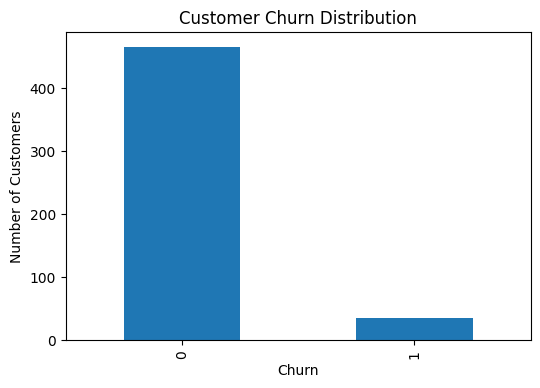

In [8]:
plt.figure(figsize=(6, 4))

data["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

# Monthly Charges vs Churn

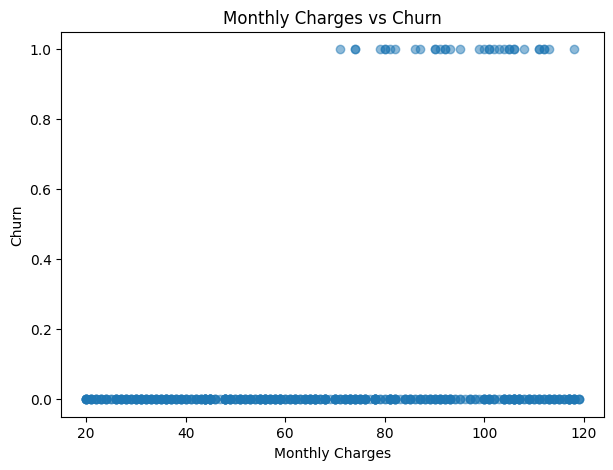

In [9]:
plt.figure(figsize=(7, 5))

plt.scatter(
    data["MonthlyCharges"],
    data["Churn"],
    alpha=0.5
)

plt.xlabel("Monthly Charges")
plt.ylabel("Churn")
plt.title("Monthly Charges vs Churn")

plt.show()

# Tenure vs Churn

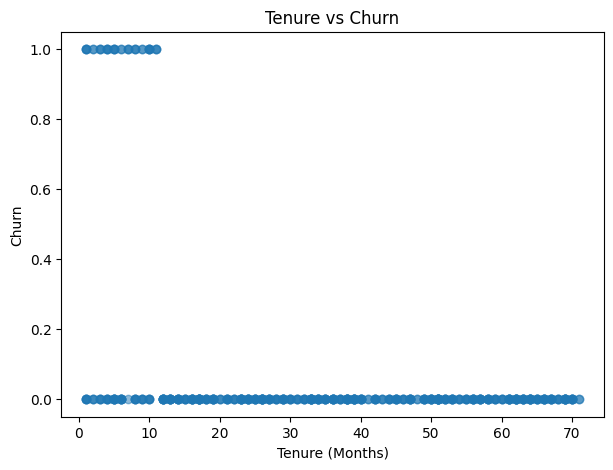

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(
    data["Tenure"],
    data["Churn"],
    alpha=0.5
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Churn")
plt.title("Tenure vs Churn")

plt.show()

# Correlation Heatmap

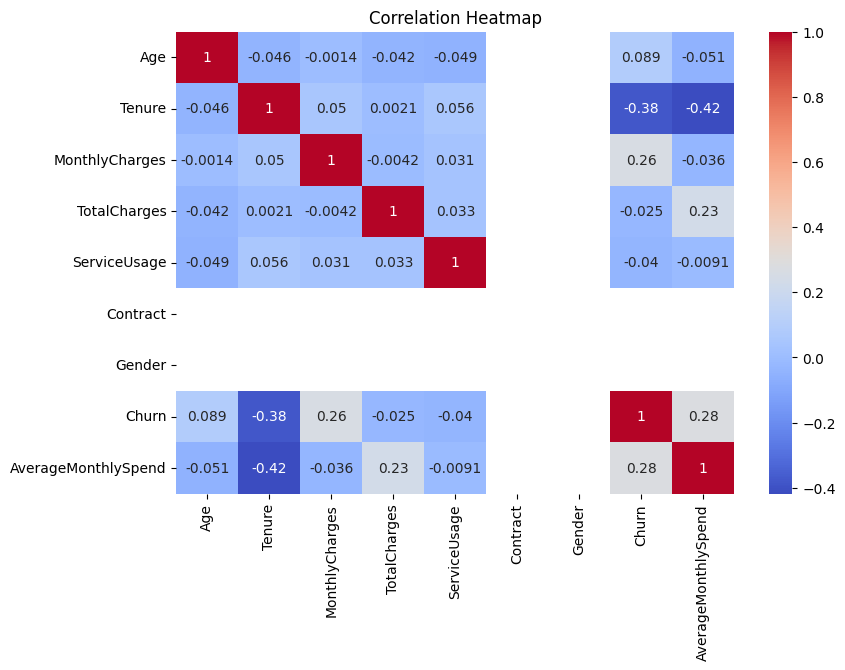

In [11]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Select input and target

In [12]:
X = data.drop("Churn", axis=1)

y = data["Churn"]


# Split the data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 400
Testing data: 100


# Create Random Forest Classifier

In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


# Make predictions

In [15]:
y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


# Calculate Accuracy

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 2))

Accuracy: 1.0


# Precision, Recall and F1 Score

In [17]:
precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


# Confusion Matrix

[[93  0]
 [ 0  7]]


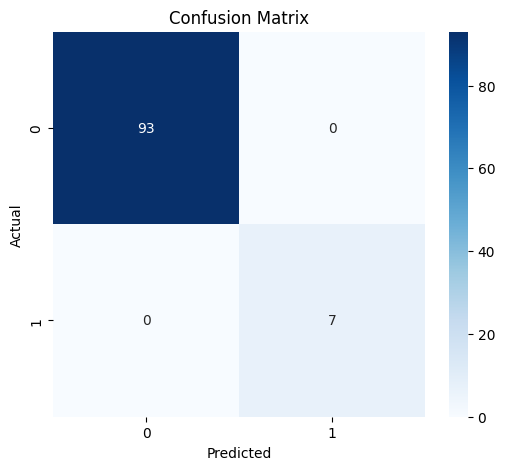

In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# . Predict a new customer

In [19]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Tenure": [5],
    "MonthlyCharges": [90],
    "TotalCharges": [450],
    "ServiceUsage": [30],
    "Contract": [0],
    "Gender": [1]
})

In [20]:
new_customer["AverageMonthlySpend"] = (
    new_customer["TotalCharges"] /
    new_customer["Tenure"]
)
prediction = model.predict(new_customer)[0]

if prediction == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is likely to STAY")

Customer is likely to CHURN


# Save the results

In [21]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully
